In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [3]:
# -------------------------------------------------
# 1. Load Wine dataset
# -------------------------------------------------
wine = load_wine()
X = wine.data
y = wine.target
class_names = wine.target_names

print("Feature matrix shape:", X.shape)
print("Classes:", np.unique(y), class_names)

Feature matrix shape: (178, 13)
Classes: [0 1 2] ['class_0' 'class_1' 'class_2']


In [4]:
# -------------------------------------------------
# 2. Train-test split
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)


In [5]:
# -------------------------------------------------
# 3. Standardize features
# -------------------------------------------------
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [6]:
# -------------------------------------------------
# 4. Baseline model: original standardized features
# -------------------------------------------------
clf_base = LogisticRegression(max_iter=2000, random_state=0)
clf_base.fit(X_train_scaled, y_train)
y_pred_base = clf_base.predict(X_test_scaled)
acc_base = accuracy_score(y_test, y_pred_base)

print("\nBaseline (original standardized features)")
print("Accuracy:", round(acc_base, 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_base))



Baseline (original standardized features)
Accuracy: 1.0
Confusion matrix:
[[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]


In [7]:
# -------------------------------------------------
# 5. LDA: reduce to 2 components
#    Wine has 3 classes, so max LDA components = 2
# -------------------------------------------------
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

clf_lda = LogisticRegression(max_iter=2000, random_state=0)
clf_lda.fit(X_train_lda, y_train)
y_pred_lda = clf_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("\nLDA (2 components)")
print("Accuracy:", round(acc_lda, 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lda))



LDA (2 components)
Accuracy: 1.0
Confusion matrix:
[[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]


In [8]:
# -------------------------------------------------
# 6. PCA: reduce to 2 components
# -------------------------------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

clf_pca = LogisticRegression(max_iter=2000, random_state=0)
clf_pca.fit(X_train_pca, y_train)
y_pred_pca = clf_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print("\nPCA (2 components)")
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum(), 4))
print("Accuracy:", round(acc_pca, 4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_pca))


PCA (2 components)
Explained variance ratio: [0.3649 0.1843]
Total variance retained: 0.5492
Accuracy: 0.9556
Confusion matrix:
[[14  1  0]
 [ 1 17  0]
 [ 0  0 12]]


In [9]:

# -------------------------------------------------
# 7. Accuracy comparison
# -------------------------------------------------
print("\n--- Accuracy Comparison ---")
print(f"Original standardized features : {acc_base:.4f}")
print(f"PCA (2 components)            : {acc_pca:.4f}")
print(f"LDA (2 components)            : {acc_lda:.4f}")


--- Accuracy Comparison ---
Original standardized features : 1.0000
PCA (2 components)            : 0.9556
LDA (2 components)            : 1.0000


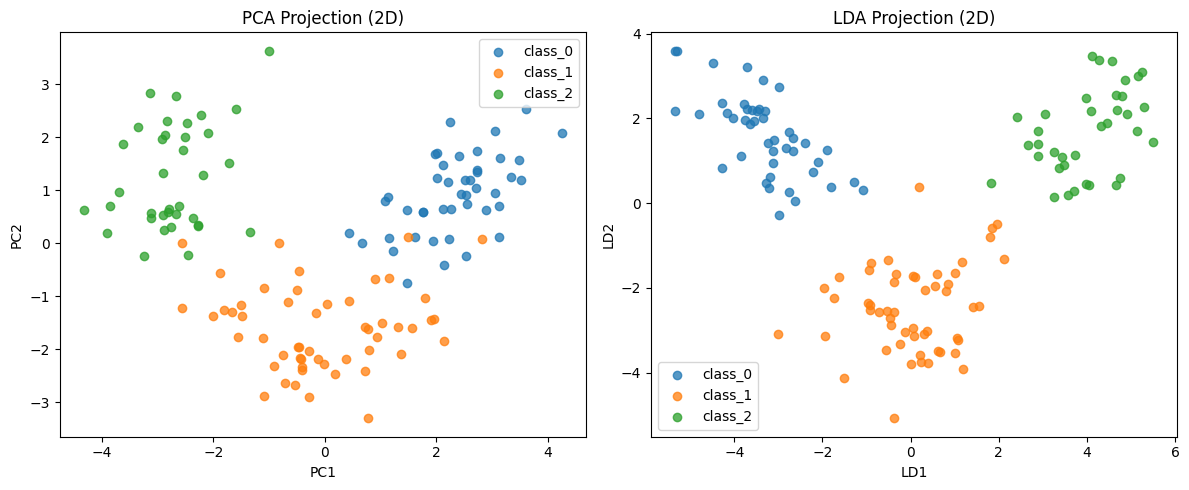

In [10]:
# -------------------------------------------------
# 8. Plot PCA and LDA projections on training data
# -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for cls in np.unique(y_train):
    axes[0].scatter(
        X_train_pca[y_train == cls, 0],
        X_train_pca[y_train == cls, 1],
        label=class_names[cls],
        alpha=0.75
    )
axes[0].set_title("PCA Projection (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

for cls in np.unique(y_train):
    axes[1].scatter(
        X_train_lda[y_train == cls, 0],
        X_train_lda[y_train == cls, 1],
        label=class_names[cls],
        alpha=0.75
    )
axes[1].set_title("LDA Projection (2D)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")
axes[1].legend()

plt.tight_layout()
plt.show()